In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("jason1966/abhinand05_crop-production-in-india")

README.md:   0%|          | 0.00/426 [00:00<?, ?B/s]

crop_production.csv: reconstructing file:   0%|          |  0.00B / 15.3MB            

crop_production.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/246091 [00:00<?, ? examples/s]

In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production'],
        num_rows: 246091
    })
})

In [3]:
df = ds["train"].to_pandas()
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0


In [113]:
df['Season'].unique()

<StringArray>
['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer', 'Winter']
Length: 6, dtype: string

In [4]:
df.shape

(246091, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [6]:
df.isnull().sum()


,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [7]:
# df['Production'] = df['Production'].fillna(df['Production'].mean())

In [8]:
df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [9]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [10]:
(df['Production'] == 0).mean()*100



np.float64(1.4315842513541739)

In [11]:
from pandas.core import groupby
((df['Production']==0).groupby(df['Crop']).mean()*100).sort_values(ascending=False).head(60)



,Production
Crop,
Apple,100.000000
Ash Gourd,100.000000
Beet Root,100.000000
Ber,100.000000
Litchi,100.000000
Lab-Lab,100.000000
Cucumber,100.000000
Plums,100.000000
Pear,100.000000


In [12]:
crop_zero_analysis = (
    df.groupby("Crop")["Production"]
      .agg(
          total_rows="size",
          zero_rows=lambda x: (x == 0).sum()
      )
)

crop_zero_analysis["zero_percentage"] = (
    crop_zero_analysis["zero_rows"]
    / crop_zero_analysis["total_rows"]
    * 100
)

crop_zero_analysis = crop_zero_analysis.sort_values(
    "zero_percentage",
    ascending=False
)

crop_zero_analysis.head(60)

,total_rows,zero_rows,zero_percentage
Crop,,,
Apple,4,4,100.000000
Ash Gourd,44,44,100.000000
Beet Root,16,16,100.000000
Ber,11,11,100.000000
Litchi,6,6,100.000000
Lab-Lab,48,48,100.000000
Cucumber,93,93,100.000000
Plums,6,6,100.000000
Pear,6,6,100.000000


In [13]:
zero_df = df[df["Production"] == 0]

zero_summary = (
    zero_df.groupby("Crop")
    .agg(
        zero_rows=("Production", "size"),
        states=("State_Name", "nunique"),
        districts=("District_Name", "nunique"),
        years=("Crop_Year", "nunique"),
        seasons=("Season", "nunique"),
        min_area=("Area", "min"),
        median_area=("Area", "median"),
        max_area=("Area", "max")
    )
    .sort_values("zero_rows", ascending=False)
)

zero_summary.head(30)

,zero_rows,states,districts,years,seasons,min_area,median_area,max_area
Crop,,,,,,,,
Other Vegetables,286,7,146,2,1,5.0,650.0,11483.0
Other Fresh Fruits,257,7,135,2,1,1.0,88.0,20570.0
Pome Fruit,128,2,67,2,1,1.0,31.5,465.0
Citrus Fruit,121,3,65,2,1,1.0,34.0,8980.0
Brinjal,119,3,62,2,1,1.0,140.0,1249.0
Bhindi,119,3,62,2,1,5.0,111.0,930.0
Mango,114,2,59,2,1,1.0,34.0,1636.0
Cabbage,107,3,57,2,1,2.0,43.0,610.0
Cauliflower,104,2,56,2,1,2.0,86.0,1348.0


In [14]:
crop_state_zero = (
    df.groupby(["Crop", "State_Name"])["Production"]
    .agg(
        total_rows="size",
        zero_rows=lambda x: (x == 0).sum()
    )
)

crop_state_zero["zero_percentage"] = (
    crop_state_zero["zero_rows"]
    / crop_state_zero["total_rows"]
    * 100
)

crop_state_zero.sort_values(
    "zero_percentage",
    ascending=False
).head(30)

total_rows  zero_rows  zero_percentage
Crop         State_Name                                            
Cucumber     Andhra Pradesh          24         24            100.0
             Tamil Nadu              51         51            100.0
             Telangana               18         18            100.0
Snak Guard   Tamil Nadu              54         54            100.0
             Kerala                  28         28            100.0
Banana       Haryana                  8          8            100.0
Grapes       Madhya Pradesh          12         12            100.0
             Rajasthan                7          7            100.0
Water Melon  Madhya Pradesh          24         24            100.0
Plums        Tamil Nadu               6          6            100.0
Water Melon  Tamil Nadu              32         32            100.0
Redish       Tamil Nadu              41         41            100.0
Lab-Lab      Tamil Nadu              48         48            100.0
Litchi       Tamil Nadu               6          6            100.0
Pump Kin     Tamil Nadu              51         51            100.0
Mango        Madhya Pradesh          84         84            100.0
             Rajasthan               30         30            100.0
Pome Granet  Tamil Nadu              45         45            100.0
Pome Fruit   Rajasthan               39         39            100.0
             Madhya Pradesh          89         89            100.0
Water Melon  Rajasthan               29         29            100.0
Bottle Gourd Andhra Pradesh          21         21            100.0
             Tamil Nadu              33         33            100.0
             Telangana               18         18            100.0
Bitter Gourd Tamil Nadu              54         54            100.0
Brinjal      Kerala                  28         28            100.0
Bitter Gourd Kerala                  28         28            100.0
Bhindi       Madhya Pradesh          91         91            100.0
Ber          Tamil Nadu              11         11            100.0
Beet Root    Tamil Nadu              16         16            100.0

In [15]:
(df['Production']==0).groupby(df['Crop_Year']).mean().sort_values(ascending=False)

,Production
Crop_Year,
2003,0.091919
2002,0.086498
1999,0.012705
2001,0.011526
2000,0.011129
2004,0.001700
2014,0.000091
2012,0.000075
2013,0.000073


In [16]:
((df['Production']==0).groupby(df['Crop']).mean()*100).sort_values(ascending=False)

,Production
Crop,
Apple,100.0
Ash Gourd,100.0
Beet Root,100.0
Ber,100.0
Litchi,100.0
...,...
Samai,0.0
Total foodgrain,0.0
Tobacco,0.0


In [17]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [18]:
df = df.drop(
    df[df["Production"] == 0].index,
    axis=0
)
df[(df["Crop"]=="Apple")]
df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [19]:
df.nlargest(20, "Production")[
    [
        "State_Name",
        "District_Name",
        "Crop_Year",
        "Season",
        "Crop",
        "Area",
        "Production"
    ]
]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
178273,Tamil Nadu,COIMBATORE,2011,Whole Year,Coconut,82704.00,1.250800e+09
178331,Tamil Nadu,COIMBATORE,2013,Whole Year,Coconut,84531.00,1.212000e+09
100654,Kerala,MALAPPURAM,2012,Whole Year,Coconut,102417.00,1.125000e+09
100612,Kerala,MALAPPURAM,2009,Whole Year,Coconut,108380.00,1.063000e+09
100149,Kerala,KOZHIKODE,1999,Whole Year,Coconut,131061.00,1.059000e+09
100391,Kerala,KOZHIKODE,2014,Whole Year,Coconut,123066.00,1.001000e+09
100135,Kerala,KOZHIKODE,1998,Whole Year,Coconut,129506.00,9.990000e+08
100598,Kerala,MALAPPURAM,2008,Whole Year,Coconut,105789.00,9.520000e+08
100373,Kerala,KOZHIKODE,2013,Whole Year,Coconut,123115.00,9.480000e+08
100639,Kerala,MALAPPURAM,2011,Whole Year,Coconut,109229.36,9.467810e+08


In [20]:
df["Production"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1]
)

,Production
0.000,1.000000e-02
0.250,9.900000e+01
0.500,7.840000e+02
0.750,7.306270e+03
0.900,6.050060e+04
0.950,1.855055e+05
0.990,1.000650e+06
0.999,1.363060e+08
1.000,1.250800e+09


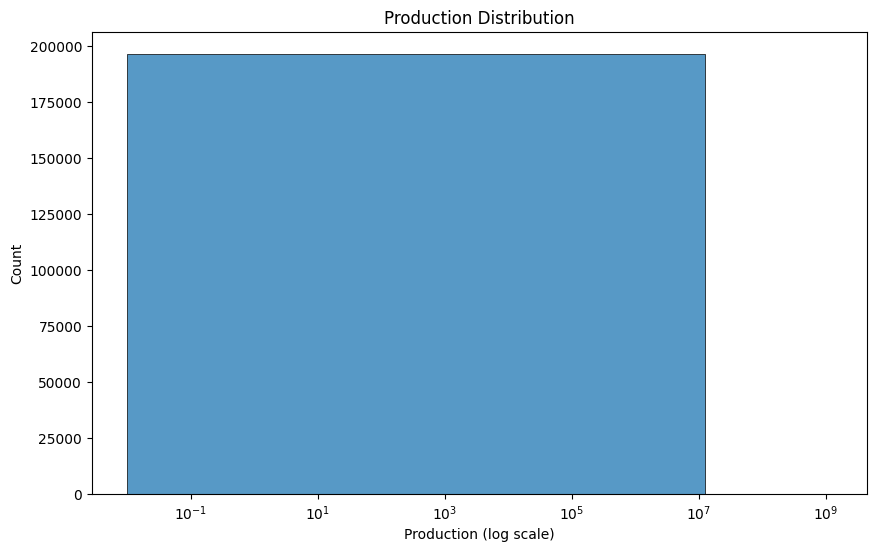

In [21]:
plot_df = df.sample(200000, random_state=42)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x="Production",
    bins=100
)

plt.xscale("log")

plt.xlabel("Production (log scale)")
plt.ylabel("Count")
plt.title("Production Distribution")
plt.show()

<Axes: xlabel='Production', ylabel='Count'>

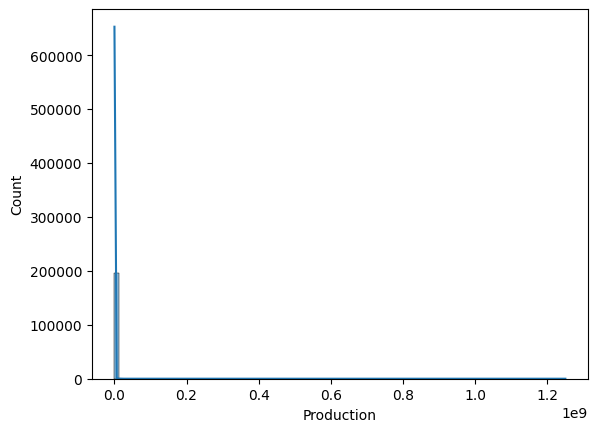

In [22]:
sns.histplot(df.sample(200000, random_state=42), x= "Production",bins=100, kde=True)

In [23]:
numeric_col = df.select_dtypes(["float64","int64"]).columns
numeric_col

Index(['Crop_Year', 'Area', 'Production'], dtype='object')

In [24]:
categorical_col = df.select_dtypes(["object"]).columns
categorical_col

Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object')

In [25]:
df.describe()

,Crop_Year,Area,Production
count,242568.000000,2.425680e+05,2.388380e+05
mean,2005.692898,1.217272e+04,5.910957e+05
std,4.968848,5.086827e+04,1.719107e+07
min,1997.000000,4.000000e-02,1.000000e-02
25%,2002.000000,8.500000e+01,9.900000e+01
50%,2006.000000,6.000000e+02,7.840000e+02
75%,2010.000000,4.543000e+03,7.306270e+03
max,2015.000000,8.580100e+06,1.250800e+09


# **Numerical columns EDA**

In [26]:
numeric_col

Index(['Crop_Year', 'Area', 'Production'], dtype='object')

In [27]:
df["Area"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1]
)

,Area
0.000,0.040
0.250,85.000
0.500,600.000
0.750,4543.000
0.900,27824.200
0.950,68585.750
0.990,190427.290
0.999,422555.207
1.000,8580100.000


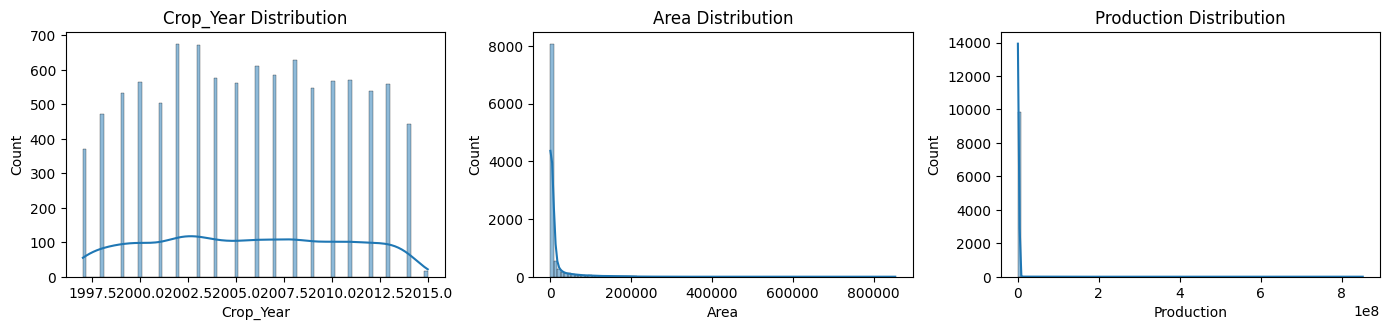

In [28]:
plt.figure(figsize=(14,6))

for i  in range(len(numeric_col)):
  plt.subplot(2,3,i+1)
  sns.histplot(data=df.sample(10000,random_state=42), x=numeric_col[i],bins=100, kde=True)
  plt.title(f"{numeric_col[i]} Distribution")
  plt.xlabel(numeric_col[i])
  plt.ylabel("Count")

plt.tight_layout()
plt.show()


## Handle null vaules

In [29]:
df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [30]:
df['Production'].isnull().groupby(df['State_Name']).sum()

,Production
State_Name,
Andaman and Nicobar Islands,2
Andhra Pradesh,67
Arunachal Pradesh,1
Assam,6
Bihar,11
Chandigarh,1
Chhattisgarh,341
Dadra and Nagar Haveli,0
Goa,1


In [31]:
df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [32]:
(df['Production'].isnull()).groupby(df['State_Name']).sum().sort_values(ascending=False)

,Production
State_Name,
Haryana,1335
Rajasthan,448
Chhattisgarh,341
Madhya Pradesh,339
Tamil Nadu,281
Kerala,258
Maharashtra,132
Uttar Pradesh,117
Gujarat,71


In [33]:
(df['Production'].isnull()).groupby(df['Crop_Year']).sum().sort_values(ascending=False)

,Production
Crop_Year,
2006,352
2009,349
2008,320
2011,280
2005,280
2010,272
1998,271
2004,259
2007,257


In [34]:
(df['Production'].isnull()).groupby(df['District_Name']).sum().sort_values(ascending=False)

,Production
District_Name,
AMBALA,96
PANIPAT,90
KAITHAL,85
YAMUNANAGAR,81
KURUKSHETRA,78
...,...
WEST KAMENG,0
WEST JAINTIA HILLS,0
24 PARAGANAS NORTH,0


In [35]:
df = df.drop(
    df[df["Production"].isna()].index,
    axis=0
).copy()

print("Production nulls:", df["Production"].isna().sum())
print("Area nulls:", df["Area"].isna().sum())
print("Area <= 0:", (df["Area"] <= 0).sum())

Production nulls: 0
Area nulls: 0
Area <= 0: 0


In [36]:
df = df.dropna()

In [37]:
df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,0


In [38]:
df['Yield'] = df['Production']/df['Area']

In [39]:
df  = df.drop("Production", axis=1)

In [40]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848


In [41]:
df.describe()

,Crop_Year,Area,Yield
count,238838.000000,2.388380e+05,238838.000000
mean,2005.676178,1.234239e+04,42.263407
std,4.975472,5.120969e+04,823.564866
min,1997.000000,1.000000e-01,0.000003
25%,2002.000000,9.100000e+01,0.532242
50%,2006.000000,6.340550e+02,1.000000
75%,2010.000000,4.700000e+03,2.400000
max,2015.000000,8.580100e+06,88000.000000


<Axes: xlabel='Yield', ylabel='Count'>

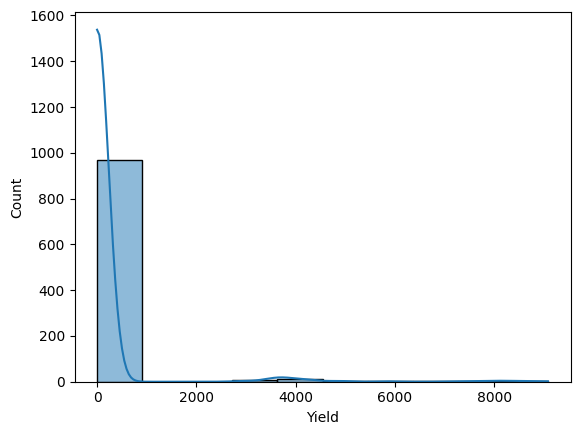

In [42]:
sns.histplot(df.head(1000), x= "Yield", bins=10, kde=True)

<Axes: ylabel='Yield'>

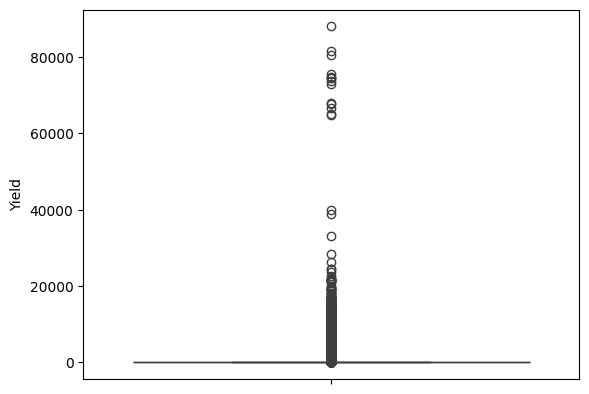

In [43]:
sns.boxplot(df, y = "Yield")

In [44]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848


In [45]:
df["log_Yield"] = np.log1p(df["Yield"])

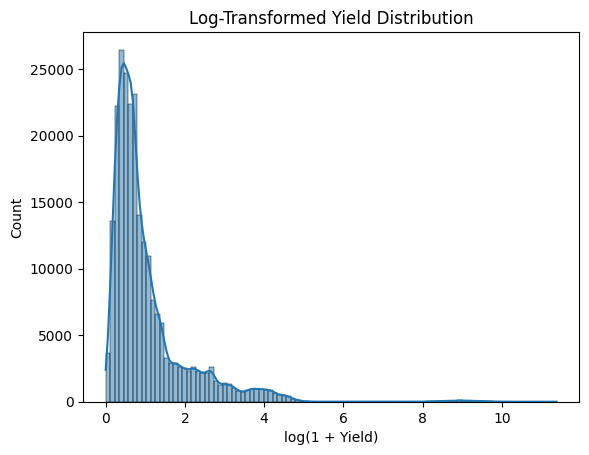

In [46]:
sns.histplot(
    df["log_Yield"],
    bins=100,
    kde=True
)

plt.title("Log-Transformed Yield Distribution")
plt.xlabel("log(1 + Yield)")
plt.ylabel("Count")
plt.show()

In [47]:
df.nlargest(20, "Yield")[
    [
        "State_Name",
        "District_Name",
        "Crop_Year",
        "Season",
        "Crop",
        "Area",
        "Yield",
        "log_Yield"
    ]
]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield,log_Yield
163866,Punjab,PATIALA,2011,Whole Year,Sugarcane,3.0,88000.000000,11.385103
164316,Punjab,SANGRUR,2011,Whole Year,Sugarcane,2.0,81500.000000,11.308371
163003,Punjab,LUDHIANA,2011,Whole Year,Sugarcane,2.0,80500.000000,11.296025
161948,Punjab,FATEHGARH SAHIB,2011,Whole Year,Sugarcane,2.0,75500.000000,11.231901
164038,Punjab,RUPNAGAR,2011,Whole Year,Sugarcane,3.0,74666.666667,11.220802
162328,Punjab,GURDASPUR,2011,Whole Year,Sugarcane,20.0,74550.000000,11.219239
163678,Punjab,PATHANKOT,2011,Whole Year,Sugarcane,4.0,74500.000000,11.218568
162835,Punjab,KAPURTHALA,2011,Whole Year,Sugarcane,3.0,73666.666667,11.207319
161967,Punjab,FAZILKA,2011,Whole Year,Sugarcane,1.0,73000.000000,11.198228
163657,Punjab,NAWANSHAHR,2011,Whole Year,Sugarcane,6.0,67833.333333,11.124824


In [48]:
df[
    (df["State_Name"] == "Punjab") &
    (df["Crop"] == "Sugarcane") &
    (df["Crop_Year"] == 2011)
][
    [
        "District_Name",
        "Area",

        "Yield",
        "log_Yield"
    ]
].sort_values("Yield", ascending=False)

,District_Name,Area,Yield,log_Yield
163866,PATIALA,3.0,88000.000000,11.385103
164316,SANGRUR,2.0,81500.000000,11.308371
163003,LUDHIANA,2.0,80500.000000,11.296025
161948,FATEHGARH SAHIB,2.0,75500.000000,11.231901
164038,RUPNAGAR,3.0,74666.666667,11.220802
162328,GURDASPUR,20.0,74550.000000,11.219239
163678,PATHANKOT,4.0,74500.000000,11.218568
162835,KAPURTHALA,3.0,73666.666667,11.207319
161967,FAZILKA,1.0,73000.000000,11.198228
163657,NAWANSHAHR,6.0,67833.333333,11.124824


In [49]:
df[
    (df["State_Name"] == "Punjab") &
    (df["Crop"] == "Sugarcane")
].groupby("Crop_Year")["Yield"].agg(
    ["count", "median", "mean", "min", "max"]
)

,count,median,mean,min,max
Crop_Year,,,,,
1997,16,57.451923,58.046965,50.909091,66.250000
1998,15,60.000000,60.698279,56.000000,66.000000
1999,15,60.000000,62.673280,54.444444,71.250000
2000,16,65.500000,65.446271,55.000000,73.333333
2001,17,68.260870,67.871512,54.000000,87.500000
2002,17,60.000000,58.853132,50.000000,70.000000
2003,16,53.666667,54.719697,46.000000,66.666667
2004,15,60.000000,60.965753,46.666667,75.000000
2005,14,65.166667,64.524814,51.000000,76.000000


In [50]:
df[
    (df["State_Name"] == "Punjab") &
    (df["Crop"] == "Sugarcane")
].groupby("Crop_Year").agg(
    rows=("Yield", "size"),
    median_area=("Area", "median"),
    median_yield=("Yield", "median"),
    max_yield=("Yield", "max")
).round(2)

,rows,median_area,median_yield,max_yield
Crop_Year,,,,
1997,16,7500.0,57.45,66.25
1998,15,5000.0,60.00,66.00
1999,15,6000.0,60.00,71.25
2000,16,6000.0,65.50,73.33
2001,17,6000.0,68.26,87.50
2002,17,8000.0,60.00,70.00
2003,16,5500.0,53.67,66.67
2004,15,3000.0,60.00,75.00
2005,14,3000.0,65.17,76.00


In [51]:
df[
    (df["State_Name"] == "Punjab") &
    (df["Crop"] == "Sugarcane")
].groupby("Crop_Year").agg(
    median_area=("Area", "median"),

    median_yield=("Yield", "median"),
    max_yield=("Yield", "max")
).round(2)

,median_area,median_yield,max_yield
Crop_Year,,,
1997,7500.0,57.45,66.25
1998,5000.0,60.00,66.00
1999,6000.0,60.00,71.25
2000,6000.0,65.50,73.33
2001,6000.0,68.26,87.50
2002,8000.0,60.00,70.00
2003,5500.0,53.67,66.67
2004,3000.0,60.00,75.00
2005,3000.0,65.17,76.00


In [52]:
(df['Crop_Year']==2011).sum()

np.int64(13791)

In [53]:
df["potential_yield_anomaly"] = (
    (df["State_Name"] == "Punjab") &
    (df["Crop"] == "Sugarcane") &
    (df["Crop_Year"] == 2011)
)

In [54]:
df["potential_yield_anomaly"].value_counts()

,count
potential_yield_anomaly,
False,238823
True,15


In [55]:
df = df[df["potential_yield_anomaly"] == False].copy()

In [56]:
print(df.shape)

(238823, 9)


In [57]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield,log_Yield,potential_yield_anomaly
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896,0.953547,False
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000,0.405465,False
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059,1.422399,False
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045,1.535155,False
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167,0.206336,False
...,...,...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647,1.285824,False
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437,0.552986,False
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321,3.934847,False
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848,1.144811,False


In [58]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield,log_Yield,potential_yield_anomaly
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896,0.953547,False
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000,0.405465,False
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059,1.422399,False
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045,1.535155,False
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167,0.206336,False
...,...,...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647,1.285824,False
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437,0.552986,False
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321,3.934847,False
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848,1.144811,False


<Axes: xlabel='log_Yield', ylabel='Count'>

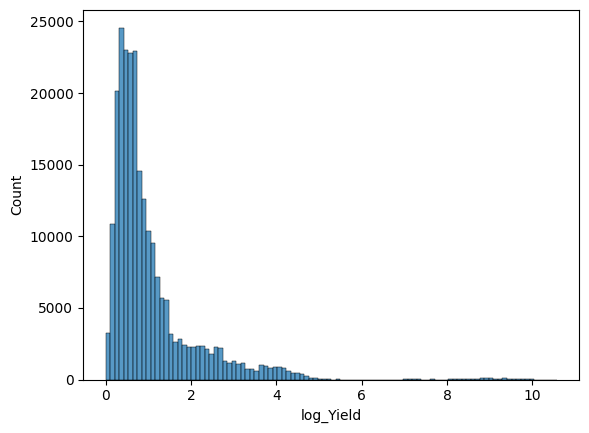

In [59]:
sns.histplot(df["log_Yield"], bins=100)


In [60]:
print(df["Yield"].describe())

count    238823.000000
mean         37.795852
std         594.682739
min           0.000003
25%           0.532209
50%           1.000000
75%           2.400000
max       38800.000000
Name: Yield, dtype: float64


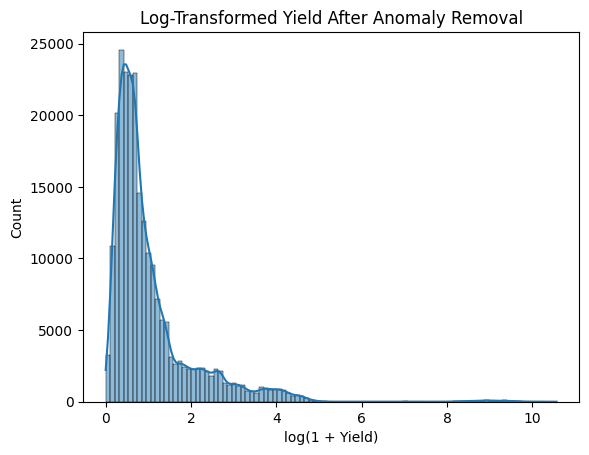

In [61]:
df["log_Yield"] = np.log1p(df["Yield"])

sns.histplot(df["log_Yield"], bins=100, kde=True)
plt.title("Log-Transformed Yield After Anomaly Removal")
plt.xlabel("log(1 + Yield)")
plt.show()

In [62]:
df.nlargest(30, "Yield")[
    [
        "State_Name",
        "District_Name",
        "Crop_Year",
        "Season",
        "Crop",
        "Area",

        "Yield"
    ]
]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield
238912,West Bengal,BIRBHUM,2006,Whole Year,Coconut,509.0,38800.000000
9829,Andhra Pradesh,WEST GODAVARI,2014,Whole Year,Coconut,21729.0,33089.005477
20171,Assam,KAMRUP,2004,Whole Year,Coconut,2026.0,28334.155972
22705,Assam,LAKHIMPUR,2001,Whole Year,Coconut,192.0,26270.833333
185975,Tamil Nadu,THANJAVUR,2011,Whole Year,Coconut,33742.0,24414.676071
18503,Assam,GOLAGHAT,2004,Whole Year,Coconut,658.0,24410.334347
7697,Andhra Pradesh,SRIKAKULAM,2014,Whole Year,Coconut,13811.0,23759.973934
236732,West Bengal,24 PARAGANAS NORTH,2006,Whole Year,Coconut,3338.0,22497.004194
18565,Assam,GOLAGHAT,2006,Whole Year,Coconut,612.0,22148.692810
18598,Assam,GOLAGHAT,2007,Whole Year,Coconut,639.0,21954.616588


In [63]:
df["Yield"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999, 1]
)

,Yield
0.900,9.992777
0.950,22.824245
0.990,83.161226
0.995,119.273248
0.999,10750.000000
1.000,38800.000000


In [64]:
crop_yield_summary = (
    df.groupby("Crop")["Yield"]
      .agg(
          count="size",
          median="median",
          mean="mean",
          max="max"
      )
      .sort_values("median", ascending=False)
)

crop_yield_summary.head(30)

,count,median,mean,max
Crop,,,,
Sugarcane,7799,53.227778,58.815579,2247.533300
Coconut,1957,43.120000,4042.468158,38800.000000
Grapes,110,23.948276,22.551417,42.927829
Banana,3104,22.000000,27.317616,138.421053
Cabbage,97,18.772222,25.069837,67.212346
Papaya,412,17.871802,33.598247,134.142636
Pineapple,247,14.647059,13.996944,32.098935
Pome Granet,21,13.400000,12.469846,16.360000
Tapioca,1583,11.450000,18.785271,70.516091


In [65]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield,log_Yield,potential_yield_anomaly
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896,0.953547,False
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000,0.405465,False
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059,1.422399,False
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045,1.535155,False
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167,0.206336,False
...,...,...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647,1.285824,False
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437,0.552986,False
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321,3.934847,False
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848,1.144811,False


In [66]:
coconut_year = (
    df[df["Crop"] == "Coconut"]
    .groupby("Crop_Year")
    .agg(
        rows=("Yield", "size"),
        median_area=("Area", "median"),
        median_yield=("Yield", "median"),
        mean_yield=("Yield", "mean"),
        max_yield=("Yield", "max")
    )
    .round(2)
)

coconut_year

,rows,median_area,median_yield,mean_yield,max_yield
Crop_Year,,,,,


In [67]:
df[df["Crop"].str.contains("Coconut", case=False, na=False)]["Crop"].value_counts()

,count
Crop,
Coconut,1957


In [68]:
cat_cols = ["State_Name", "District_Name", "Season", "Crop"]

for col in cat_cols:
    df[col] = df[col].astype("string").str.strip()

In [69]:
print(repr(df.loc[df["Crop"].str.contains("Coconut", case=False, na=False), "Crop"].iloc[0]))

'Coconut'


In [70]:
coconut_df = df[df["Crop"] == "Coconut"].copy()

coconut_year = (
    coconut_df
    .groupby("Crop_Year")
    .agg(
        rows=("Yield", "size"),
        median_area=("Area", "median"),
        median_yield=("Yield", "median"),
        mean_yield=("Yield", "mean"),
        max_yield=("Yield", "max")
    )
    .round(2)
)

print(coconut_year.to_string())

           rows  median_area  median_yield  mean_yield  max_yield
Crop_Year                                                        
1997         57       1040.0          5.61        7.62      20.98
1998         83       1174.0         17.33     2578.83    9908.82
1999         86       1161.5         17.77     3025.74   16500.00
2000        108       1172.5       3752.31     4068.83   18000.00
2001        107       1264.0       3583.78     4349.99   26270.83
2002        134       2105.5         15.44     3435.53   14432.86
2003        133       2101.0         16.10     3459.37   16906.30
2004        138       2177.5         48.24     3878.03   28334.16
2005        114       4480.0          5.02     2567.27   16500.00
2006        139       2101.0       4073.97     5265.60   38800.00
2007        123       2310.0       1777.78     4558.23   21954.62
2008        138       1706.5        177.51     3703.48   21082.31
2009        122       2301.5       2181.64     4427.09   18829.77
2010      

In [71]:
print(
    coconut_year
    .sort_values("max_yield", ascending=False)
    .head(30)
    .to_string()
)

           rows  median_area  median_yield  mean_yield  max_yield
Crop_Year                                                        
2006        139       2101.0       4073.97     5265.60   38800.00
2014         64       6409.5         19.30     5598.35   33089.01
2004        138       2177.5         48.24     3878.03   28334.16
2001        107       1264.0       3583.78     4349.99   26270.83
2011        124       2303.5       5610.69     6240.43   24414.68
2007        123       2310.0       1777.78     4558.23   21954.62
2012         87       1394.0          9.85     3792.14   21285.00
2008        138       1706.5        177.51     3703.48   21082.31
2013        122       2793.5        917.34     4921.00   21021.03
2009        122       2301.5       2181.64     4427.09   18829.77
2000        108       1172.5       3752.31     4068.83   18000.00
2003        133       2101.0         16.10     3459.37   16906.30
1999         86       1161.5         17.77     3025.74   16500.00
2005      

In [72]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Yield', 'log_Yield', 'potential_yield_anomaly'],
      dtype='object')

In [73]:
coconut_state = (
    df[df["Crop"] == "Coconut"]
    .groupby("State_Name")
    .agg(
        rows=("Yield", "size"),
        median_area=("Area", "median"),
        median_yield=("Yield", "median"),
        mean_yield=("Yield", "mean"),
        max_yield=("Yield", "max")
    )
    .sort_values("median_yield", ascending=False)
)

print(coconut_state.to_string())

                             rows  median_area  median_yield    mean_yield     max_yield
State_Name                                                                              
Puducherry                     57       318.00  11336.126629  11563.106646  19792.982456
Telangana                      52        12.50  11105.057257  10366.802670  14606.000000
Andhra Pradesh                169      1829.00  10282.390357  10689.470339  33089.005477
Kerala                        252     58475.00   6306.290641   5944.032734  11051.715759
Assam                         400       556.00   5257.042107   5295.174751  28334.155972
Goa                            12     12738.00   4930.284855   3304.837533   4995.103525
Andaman and Nicobar Islands    18      7133.35   3749.091268   3796.015617   4896.978022
West Bengal                   216       858.50     14.225000   2147.189261  38800.000000
Tamil Nadu                    291      6916.00     10.292548   2453.580385  24414.676071
Karnataka            

# Categorical Columns EDA

In [74]:
categorical_col

Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object')

<Axes: xlabel='count', ylabel='Season'>

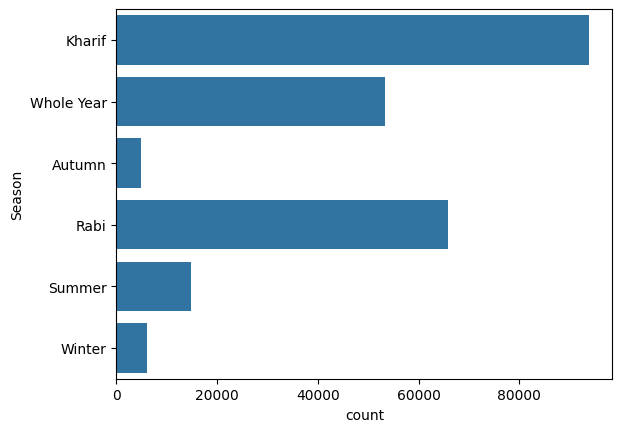

In [75]:
sns.countplot(y=df['Season'])

<Axes: >

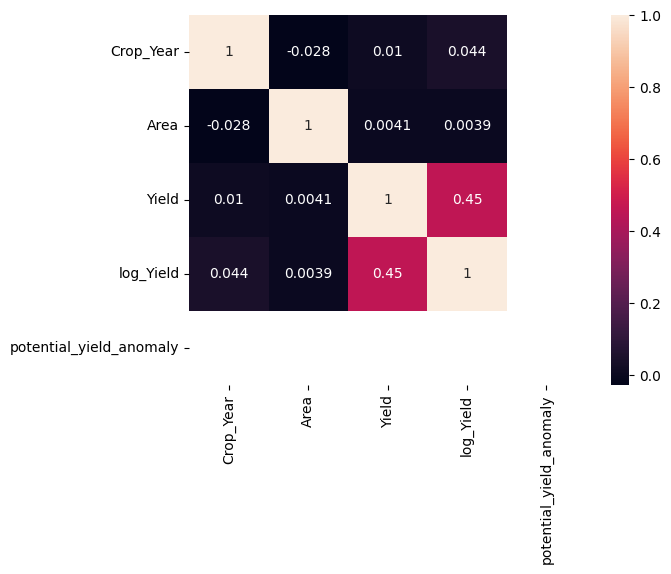

In [76]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [77]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield,log_Yield,potential_yield_anomaly
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896,0.953547,False
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000,0.405465,False
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059,1.422399,False
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045,1.535155,False
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167,0.206336,False
...,...,...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647,1.285824,False
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437,0.552986,False
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321,3.934847,False
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848,1.144811,False


In [78]:
df =df.drop(['potential_yield_anomaly'],axis=1)

In [79]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield,log_Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896,0.953547
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000,0.405465
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059,1.422399
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045,1.535155
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167,0.206336
...,...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,2.617647,1.285824
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,0.738437,0.552986
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,50.154321,3.934847
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,2.141848,1.144811


In [80]:
X = df.drop(['Yield',"log_Yield"], axis=1)
y = df['Yield']
y_log = df['log_Yield']

In [81]:
X.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238823 entries, 0 to 246090
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     238823 non-null  string 
 1   District_Name  238823 non-null  string 
 2   Crop_Year      238823 non-null  int64  
 3   Season         238823 non-null  string 
 4   Crop           238823 non-null  string 
 5   Area           238823 non-null  float64
dtypes: float64(1), int64(1), string(4)
memory usage: 12.8 MB
<class 'pandas.core.frame.DataFrame'>
Index: 238823 entries, 0 to 246090
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     238823 non-null  string 
 1   District_Name  238823 non-null  string 
 2   Crop_Year      238823 non-null  int64  
 3   Season         238823 non-null  string 
 4   Crop           238823 non-null  string 
 5   Area           238823 non-null  float64
 6   Yie

In [82]:
categorical_col = X.select_dtypes("string").columns
numeric_col = X.select_dtypes(["int64","float64"]).columns

In [83]:
from multiprocessing import Pipe
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import  r2_score, mean_absolute_error,mean_squared_error


numeric_col_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_col_pipline = Pipeline(steps=[
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessing_pipeline = ColumnTransformer(transformers=[
    ("numeric_pipeline", numeric_col_pipeline, numeric_col),
    ("categorical_pipline", categorical_col_pipline, categorical_col)
])


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.20, random_state=42)

model_ridge = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('model', Ridge())
])

model_ridge.fit(X_train,y_train)
y_ridge_pred = model_ridge.predict(X_test)

r2_score(y_test, y_ridge_pred)
mean_absolute_error(y_test,y_ridge_pred)



0.269340988186105

In [105]:
from sklearn.model_selection import RandomizedSearchCV

# random_cv = RandomizedSearchCV(n_iter=[100,200,300]
#                                cv=[5,6,7])
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=9,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.7,
    min_child_weight=3,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)
model_xgboost = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('model', xgb_model)
])

model_xgboost.fit(X_train,y_train)
y_xgboost_pred_test = model_xgboost.predict(X_test)
y_xgboost_pred_train = model_xgboost.predict(X_train)

print(f"Train: {r2_score(y_train, y_xgboost_pred_train)}")
print(f"Test: {r2_score(y_test, y_xgboost_pred_test)}")
print(f"mean_absolute_error : {mean_absolute_error(y_test, y_xgboost_pred_test)}")



Train: 0.9633921530146986
Test: 0.960063024154825
mean_absolute_error : 0.13894595199465407


In [107]:
import joblib
joblib.dump(model_xgboost,"model_xgboost.pkl")

['model_xgboost.pkl']

In [103]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the hyperparameter search space (use "model__" prefix if using a Pipeline)
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10, 20],
}

# 2. Configure RandomizedSearchCV with single integers for n_iter and cv
random_cv = RandomizedSearchCV(
    estimator=model_xgboost,
    param_distributions=param_distributions,
    n_iter=10,  # Number of random parameter combinations to try
    cv=5,  # 5-fold cross-validation
    scoring="r2",
    random_state=42,
    n_jobs=-1,  # Uses all CPU cores
)

# 3. Fit on training data
random_cv.fit(X_train, y_train)

best_model = random_cv.best_estimator_

y_random_cv_pred_test = best_model.predict(X_test)
y_random_cv_pred_train = best_model.predict(X_train)

print(f"Train: {y_random_cv_pred_train}")
print(f"Test: {y_random_cv_pred_test}")
print(f"mean_absolute_error : {mean_absolute_error(y_test, y_random_cv_pred_test)}")
print(f"mean_squared_error : {mean_squared_error(y_test, y_random_cv_pred_test)}")



# 4. View best results
print("Best Parameters:", random_cv.best_params_)
print("Best R2 Score:", random_cv.best_score_)
print("Error:", random_cv.error_score)

Train: [0.75096595 0.5907636  0.25041693 ... 0.28212643 0.28059486 0.8934605 ]
Test: [2.6433492  0.8070697  2.0694482  ... 0.66068673 0.27933678 0.30816752]
mean_absolute_error : 0.13828027924936806
mean_squared_error : 0.04302676675123795
Best Parameters: {'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 9, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.7}
Best R2 Score: 0.9541547619514217
Error: nan


In [87]:
import numpy as np
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Predictions on log scale
pred_log = best_model.predict(X_test)

# Convert back to original Yield scale
pred_yield = np.expm1(pred_log)
actual_yield = np.expm1(y_test)

# Metrics on original Yield scale
r2 = r2_score(actual_yield, pred_yield)
mae = mean_absolute_error(actual_yield, pred_yield)
mse = mean_squared_error(actual_yield, pred_yield)
rmse = np.sqrt(mse)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

R²   : 0.7533
MAE  : 13.5599
MSE  : 90672.5934
RMSE : 301.1189


In [88]:
# Metrics on original Yield scale
r2_xg_test = r2_score(y_test, y_random_cv_pred_test)
r2_xg_train = r2_score(y_train, y_random_cv_pred_train)
mae_xg = mean_absolute_error(y_test, y_random_cv_pred_test)
mse_xg = mean_squared_error(y_test, y_random_cv_pred_test)
rmse_xg = np.sqrt(mse)

print(f"R² Train   : {r2_xg_train:.4f}")
print(f"R² Test   : {r2_xg_test:.4f}")
print(f"MAE  : {mae_xg:.4f}")
print(f"MSE  : {mse_xg:.4f}")
print(f"RMSE : {rmse_xg:.4f}")

R² Train   : 0.9633
R² Test   : 0.9599
MAE  : 0.1383
MSE  : 0.0430
RMSE : 301.1189


In [89]:
print(df["Crop_Year"].value_counts().sort_index())

Crop_Year
1997     8899
1998    11262
1999    12282
2000    13401
2001    13139
2002    15094
2003    15550
2004    13834
2005    13519
2006    13976
2007    14269
2008    14230
2009    13767
2010    13793
2011    13776
2012    13183
2013    13474
2014    10814
2015      561
Name: count, dtype: int64


In [90]:
cut_off_year = 2014
train_df = df[df['Crop_Year']<cut_off_year]
test_df = df[df['Crop_Year']>=cut_off_year]

xgb_params = {
    "n_estimators"        : 300,
    "max_depth"           : 9,
    "learning_rate"       : 0.2,
    "subsample"           : 1.0,
    "colsample_bytree"    : 0.7,
    "min_child_weight"    : 3,
    "reg_alpha"           : 1,
    "reg_lambda"          : 1
}

time_model = Pipeline(steps = [
    ("preprocessing", preprocessing_pipeline),
    ("model",XGBRegressor(
        **xgb_params,
        random_state=42

    ))
])

X_train_time = train_df.drop(["Yield","log_Yield"],axis=1)
y_train_time = train_df["log_Yield"]

X_test_time = test_df.drop(["Yield","log_Yield"],axis=1)
y_test_time = test_df["log_Yield"]

time_model.fit(
    X_train_time,
    y_train_time
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric_pipeline',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Crop_Year', 'Area'], dtype='object')),
                                                 ('categorical_pipline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object'))])),
                ('model',
                 X...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.2,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=9, max_leaves=None, min_child_weight=3,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=300,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [91]:
pred_time_log = time_model.predict(X_test_time)

In [92]:
r2_time = r2_score(
    y_test_time,
    pred_time_log
)

mae_time = mean_absolute_error(
    y_test_time,
    pred_time_log
)

mse_time = mean_squared_error(
    y_test_time,
    pred_time_log
)

rmse_time = np.sqrt(mse_time)

print(f"Time-based Test R²   : {r2_time:.4f}")
print(f"Time-based Test MAE  : {mae_time:.4f}")
print(f"Time-based Test MSE  : {mse_time:.4f}")
print(f"Time-based Test RMSE : {rmse_time:.4f}")

Time-based Test R²   : 0.9454
Time-based Test MAE  : 0.1557
Time-based Test MSE  : 0.0570
Time-based Test RMSE : 0.2387


In [93]:
year_results = test_df[[
    "Crop_Year",
    "State_Name",
    "District_Name",
    "Crop",
    "Season",
    "Area"
]].copy()

year_results["actual_log_yield"] = y_test_time.values
year_results["predicted_log_yield"] = pred_time_log

year_metrics = year_results.groupby("Crop_Year").apply(
    lambda x: pd.Series({
        "R2": r2_score(
            x["actual_log_yield"],
            x["predicted_log_yield"]
        ),
        "MAE": mean_absolute_error(
            x["actual_log_yield"],
            x["predicted_log_yield"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                x["actual_log_yield"],
                x["predicted_log_yield"]
            )
        ),
        "Count": len(x)
    })
)

print(year_metrics)

                 R2       MAE      RMSE    Count
Crop_Year                                       
2014       0.944863  0.156671  0.240548  10814.0
2015       0.952750  0.137614  0.198994    561.0


/tmp/ipykernel_7222/1276492116.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_metrics = year_results.groupby("Crop_Year").apply(


In [96]:

loaded_model = joblib.load("crop_yield_model.pkl")

print(loaded_model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric_pipeline',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Crop_Year', 'Area'], dtype='object')),
                                                 ('categorical_pipline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object'))])),
                ('model',
                 X...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
             

In [97]:
X.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area'], dtype='object')

3.4.1
xgboost: 3.4.1
sklearn: 1.6.1
joblib: 1.6.0


In [109]:
model = joblib.load("model_xgboost.pkl")
y_pred = model.predict(X_test)

r2_score(y_test,y_pred)

0.960063024154825

In [110]:
import joblib
from xgboost import XGBRegressor

# ------------------------------------------------------------
# Extract fitted components from your tuned Pipeline
# ------------------------------------------------------------

best_preprocessor = model_xgboost.named_steps["preprocessing"]
best_xgb_model = model_xgboost.named_steps["model"]


# ------------------------------------------------------------
# Verify that this is your tuned XGBoost
# ------------------------------------------------------------

print("n_estimators:",
      best_xgb_model.get_params()["n_estimators"])

print("max_depth:",
      best_xgb_model.get_params()["max_depth"])

print("learning_rate:",
      best_xgb_model.get_params()["learning_rate"])

print("subsample:",
      best_xgb_model.get_params()["subsample"])

print("colsample_bytree:",
      best_xgb_model.get_params()["colsample_bytree"])

print("min_child_weight:",
      best_xgb_model.get_params()["min_child_weight"])

print("reg_alpha:",
      best_xgb_model.get_params()["reg_alpha"])

print("reg_lambda:",
      best_xgb_model.get_params()["reg_lambda"])

n_estimators: 300
max_depth: 9
learning_rate: 0.2
subsample: 1.0
colsample_bytree: 0.7
min_child_weight: 3
reg_alpha: 1
reg_lambda: 1


In [111]:
joblib.dump(
    best_preprocessor,
    "crop_yield_preprocessor.pkl"
)

print("Preprocessor saved.")

Preprocessor saved.


In [112]:
best_xgb_model.save_model(
    "xgboost_model.json"
)

print("XGBoost model saved.")

XGBoost model saved.
